# Loan Risk Analysis
### From public loan records to an explainable scoring exercise

**Question:** Can six application-time fields help rank which historically funded,
resolved loans were eventually charged off? Compare logistic regression and one small
decision tree, then illustrate approve / review / decline routing.

**Read in order:** source and audit → SQL → fixed time split → validation comparison →
frozen routing → final evaluation → boundary checks. All outputs come from running this
notebook. It also regenerates the short README with the results from the current run.

This is retrospective portfolio research. The target is eventual **charged off (1)**
versus **fully paid (0)**, not a one-year default probability or a real lending policy.

## 1. Source and choices fixed before fitting

Source: Ariza-Garzón, Sanz-Guerrero, Arroyo Gallardo and Lending Club (2024),
[Lending Club loan dataset for granting models, version 0.1](https://doi.org/10.5281/zenodo.11295916).
The source is already curated; the work here is an audit and preparation of a reproducible sample.

- Sample 50,000 rows uniformly without replacement from the complete file; seed 42.
- Train on originations before 2016; validate on 2016; test on 2017–2018.
  Whole months stay together. These dates are not adjusted to improve scores.
- Use income, DTI, requested amount, FICO, employment length and purpose.
  Exclude IDs and dates from predictors. Exclude the outcome and post-origination fields.
- Fit one logistic regression and one depth-3 tree. Select by validation ROC-AUC;
  an exact tie goes to logistic regression. No search or refitting on validation.
- Use the selected model's validation score terciles for two illustrative cutoffs.
  This demonstrates approximately equal-sized routing groups, not optimal lending economics.
- Freeze the model and cutoffs before computing final-test predictions. A fresh rerun
  reproduces the same experiment; it is not an independent new holdout.

In [1]:
from pathlib import Path
import hashlib
import platform
import sqlite3
import urllib.request
import warnings
from numbers import Real

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text
import sklearn

ROOT = Path.cwd()
assert (ROOT / 'loan_audit.sql').exists(), 'Run from the project folder.'
DATA = ROOT / 'data'
DATA.mkdir(exist_ok=True)
SEED, SAMPLE_SIZE = 42, 50_000
VALID_START, TEST_START = pd.Timestamp('2016-01-01'), pd.Timestamp('2017-01-01')
NUMERIC = ['revenue', 'dti_n', 'loan_amnt', 'fico_n']
CATEGORICAL = ['emp_length', 'purpose']
FEATURES = NUMERIC + CATEGORICAL
COLUMNS = ['id', 'issue_d'] + FEATURES + ['Default']
SOURCE_URL = 'https://zenodo.org/records/11295916/files/LC_loans_granting_model_dataset.csv?download=1'
EXPECTED_MD5 = 'b019384d6bc65bf2a3e839362e4ff502'
SOURCE_FILE = DATA / 'LC_loans_granting_model_dataset.csv'
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
warnings.filterwarnings('error', category=ConvergenceWarning)
print(f'Python {platform.python_version()} | pandas {pd.__version__} | '
      f'NumPy {np.__version__} | scikit-learn {sklearn.__version__}')

Python 3.12.14 | pandas 2.2.3 | NumPy 2.2.6 | scikit-learn 1.6.1


In [2]:
def file_md5(path):
    digest = hashlib.md5()
    with path.open('rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()

if not SOURCE_FILE.exists():
    # A partial download never replaces the final cache file.
    partial = SOURCE_FILE.with_suffix('.csv.part')
    urllib.request.urlretrieve(SOURCE_URL, partial)
    assert file_md5(partial) == EXPECTED_MD5, 'Downloaded source checksum differs.'
    partial.replace(SOURCE_FILE)
assert file_md5(SOURCE_FILE) == EXPECTED_MD5, 'Cached source checksum differs; inspect the file.'

# Only the nine needed columns are loaded, not the loan descriptions or addresses.
source = pd.read_csv(SOURCE_FILE, usecols=COLUMNS, dtype={'id': 'string'})[COLUMNS]
source_rows = len(source)
source_duplicate_ids = int(source['id'].duplicated().sum())
assert source_rows == 1_347_681
assert source['id'].notna().all() and source_duplicate_ids == 0
sample = source.sample(n=SAMPLE_SIZE, replace=False, random_state=SEED).reset_index(drop=True)
del source
sample_id_hash = hashlib.sha256('\n'.join(sample['id']).encode()).hexdigest()
print(f'Source: {source_rows:,} rows | duplicate IDs: {source_duplicate_ids}')
print(f'Sample: {sample.shape} | seed: {SEED} | verified source MD5: {EXPECTED_MD5}')
print('Sample ID SHA-256:', sample_id_hash)
print('Columns:', sample.columns.tolist())
display(sample.head())

Source: 1,347,681 rows | duplicate IDs: 0
Sample: (50000, 9) | seed: 42 | verified source MD5: b019384d6bc65bf2a3e839362e4ff502
Sample ID SHA-256: efa1046a2505b05d3b7281ddde92f481c55f6e24e084b2a76cdecf52f0fb2ecc
Columns: ['id', 'issue_d', 'revenue', 'dti_n', 'loan_amnt', 'fico_n', 'emp_length', 'purpose', 'Default']


,id,issue_d,revenue,dti_n,loan_amnt,fico_n,emp_length,purpose,Default
0,77329604,Apr-2016,"60,000.0000",13.2200,5000,662.0000,10+ years,debt_consolidation,0
1,38341768,Jan-2015,"75,000.0000",11.7800,30000,662.0000,3 years,debt_consolidation,1
2,50627339,Jun-2015,"91,000.0000",27.9800,25000,727.0000,1 year,debt_consolidation,0
3,85734476,Jul-2016,"94,000.0000",29.4400,22825,662.0000,10+ years,debt_consolidation,1
4,3236952,Jul-2013,"60,000.0000",18.6600,26500,712.0000,10+ years,debt_consolidation,0


## 2. Audit and deterministic preparation

Parse dates using the source's month-year format; stop on invalid dates, targets or IDs.
Check numeric ranges before imputation. Invalid nonfinite values, nonpositive income/amount,
negative DTI and FICO outside 300–850 become missing. No rows are silently dropped.
Retain unusual but admissible values: high DTI is not automatically a data error.
Log-transform income and amount in the pipeline to reduce the influence of their long tails.
DTI remains on its original scale; no outcome-driven clipping is used.

Treat employment `NI` as missing information and encode it as `Unknown`. Missing numeric
values use training medians; missing categories use a fixed `Unknown` label. The curated
sample can have no ordinary nulls and still contain coded missing information.

In [3]:
loans = sample.rename(columns={'Default': 'charged_off'}).copy()
loans['issue_d'] = pd.to_datetime(loans['issue_d'], format='%b-%Y', errors='coerce')
assert loans['issue_d'].notna().all(), 'Invalid origination date.'
assert loans['issue_d'].between('2007-01-01', '2018-12-01').all()
assert loans['charged_off'].isin([0, 1]).all(), 'Unexpected target label.'
assert loans['id'].notna().all() and loans['id'].is_unique
assert not loans.duplicated().any()
loans['charged_off'] = loans['charged_off'].astype('int64')

audit = pd.DataFrame({'raw_nulls': sample[FEATURES].isna().sum()})
for name in NUMERIC:
    values = pd.to_numeric(loans[name], errors='coerce')
    valid = np.isfinite(values)
    if name in ['revenue', 'loan_amnt']:
        valid &= values > 0
    elif name == 'dti_n':
        valid &= values >= 0
    else:
        valid &= values.between(300, 850)
    audit.loc[name, 'invalid_nonmissing'] = int((loans[name].notna() & ~valid).sum())
    loans[name] = values.where(valid, np.nan)
for name in CATEGORICAL:
    loans[name] = loans[name].astype('object').replace(r'^\s*$', np.nan, regex=True)
employment_ni = int(loans['emp_length'].eq('NI').sum())
loans['emp_length'] = loans['emp_length'].replace('NI', np.nan)
audit['invalid_nonmissing'] = audit['invalid_nonmissing'].fillna(0).astype(int)
audit['prepared_missing'] = loans[FEATURES].isna().sum()
extremes = {'income_above_1m': int((loans['revenue'] > 1_000_000).sum()),
            'dti_above_100': int((loans['dti_n'] > 100).sum())}
display(audit)
display(loans[NUMERIC].describe())
print('Employment NI converted to missing:', employment_ni)
print('Retained extreme values:', extremes)
print('Missing IDs, duplicate IDs, duplicate rows, invalid dates and targets: 0')
assert len(loans) == SAMPLE_SIZE
loans = loans.sort_values(['issue_d', 'id']).reset_index(drop=True)

,raw_nulls,invalid_nonmissing,prepared_missing
revenue,0,0,0
dti_n,0,0,0
loan_amnt,0,0,0
fico_n,0,0,0
emp_length,0,0,2886
purpose,0,0,0


,revenue,dti_n,loan_amnt,fico_n
count,"50,000.0000","50,000.0000","50,000.0000","50,000.0000"
mean,"77,471.7593",18.2564,"14,418.6675",698.2423
std,"73,009.0008",10.3736,"8,742.5272",31.8960
min,"4,888.0000",0.0000,800.0000,642.0000
25%,"46,227.2500",11.8000,"7,918.7500",672.0000
50%,"65,000.0000",17.6200,"12,000.0000",692.0000
75%,"93,000.0000",24.0300,"20,000.0000",712.0000
max,"8,706,582.0000",999.0000,"40,000.0000",847.5000


Employment NI converted to missing: 2886
Retained extreme values: {'income_above_1m': 10, 'dti_above_100': 17}
Missing IDs, duplicate IDs, duplicate rows, invalid dates and targets: 0


## 3. SQLite: two useful reconciliations

The SQL file groups the same sample by origination year and loan purpose, independently
of pandas. Counts and charged-off totals must reconcile to the input. Yearly rates expose
cohort changes; purpose rates describe composition, not causal effects. These are descriptive
audits and do not determine features, split dates or model parameters.

In [4]:
sql_loans = loans.copy()
sql_loans['issue_d'] = sql_loans['issue_d'].dt.strftime('%Y-%m-%d')
statements = [query.strip() for query in (ROOT / 'loan_audit.sql').read_text().split(';')
              if query.strip()]
assert len(statements) == 2
with sqlite3.connect(DATA / 'loan_risk.sqlite') as connection:
    sql_loans.to_sql('loans', connection, if_exists='replace', index=False)
    by_year, by_purpose = [pd.read_sql_query(query, connection) for query in statements]

for result in [by_year, by_purpose]:
    assert result['loan_count'].sum() == len(loans)
    assert result['charged_off_count'].sum() == loans['charged_off'].sum()
    np.testing.assert_allclose(result['charged_off_rate'],
                               result['charged_off_count'] / result['loan_count'])
display(by_year)
display(by_purpose)
print('Both SQL queries reconcile to the Python sample.')

,origination_year,loan_count,charged_off_count,charged_off_rate
0,2007,15,3,0.2000
1,2008,103,23,0.2233
2,2009,194,25,0.1289
3,2010,490,68,0.1388
4,2011,808,115,0.1423
5,2012,1897,308,0.1624
6,2013,5066,744,0.1469
7,2014,8226,1532,0.1862
8,2015,13893,2773,0.1996
9,2016,10965,2585,0.2358


,purpose,loan_count,charged_off_count,charged_off_rate
0,debt_consolidation,28913,6076,0.2101
1,credit_card,11089,1887,0.1702
2,home_improvement,3217,593,0.1843
3,other,2887,608,0.2106
4,major_purchase,1129,229,0.2028
5,small_business,594,177,0.2980
6,medical,547,106,0.1938
7,car,512,70,0.1367
8,moving,362,84,0.2320
9,vacation,344,67,0.1948


Both SQL queries reconcile to the Python sample.


## 4. Fix chronological groups

The split uses origination dates rather than a random train/test split. It asks whether
ranking carries into later cohorts. Because the extract contains only resolved loans and
does not supply resolution dates, it is **not** a reconstruction of the labels a lender
would have known in 2016. Later cohorts can overrepresent quickly resolved loans.

In [5]:
train = loans.loc[loans['issue_d'] < VALID_START].copy()
validation = loans.loc[loans['issue_d'].between(VALID_START, TEST_START, inclusive='left')].copy()
test = loans.loc[loans['issue_d'] >= TEST_START].copy()
groups = {'Train': train, 'Validation': validation, 'Final test': test}
assert sum(map(len, groups.values())) == len(loans)
assert train['issue_d'].max() < validation['issue_d'].min()
assert validation['issue_d'].max() < test['issue_d'].min()
assert set(train.id).isdisjoint(validation.id) and set(train.id).isdisjoint(test.id)
assert set(validation.id).isdisjoint(test.id)
assert all(group['charged_off'].nunique() == 2 for group in groups.values())
split_summary = pd.DataFrame([
    {'split': name, 'rows': len(group), 'start': group.issue_d.min().strftime('%Y-%m'),
     'end': group.issue_d.max().strftime('%Y-%m'),
     'charged_off_count': int(group.charged_off.sum()),
     'charged_off_rate': group.charged_off.mean()}
    for name, group in groups.items()
])
display(split_summary)
X_train, y_train = train[FEATURES], train['charged_off']
X_validation, y_validation = validation[FEATURES], validation['charged_off']
assert {'id', 'issue_d', 'charged_off', 'Default'}.isdisjoint(FEATURES)

,split,rows,start,end,charged_off_count,charged_off_rate
0,Train,30692,2007-07,2015-12,5591,0.1822
1,Validation,10965,2016-01,2016-12,2585,0.2358
2,Final test,8343,2017-01,2018-12,1797,0.2154


## 5. Fit two small, explainable pipelines

Logistic regression combines weighted inputs on a log-odds scale. The depth-3 decision
tree uses at most eight leaves and a minimum of 200 training loans per leaf. Neither
model receives class weights or resampled outcomes. Their probability-like outputs are
used as **scores**; calibration has not been established.

Each model gets a separate preprocessor. Imputation, scaling and the one-hot vocabulary
are fitted only on training data, following
[scikit-learn's pipeline guidance](https://scikit-learn.org/stable/common_pitfalls.html).
Unknown categories are accepted by the encoder, but that alone does not establish
reliable performance for a new category.

In [6]:
def make_preprocessor():
    return ColumnTransformer([
        ('money', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
            ('scale', StandardScaler())
        ]), ['revenue', 'loan_amnt']),
        ('numeric', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())
        ]), ['dti_n', 'fico_n']),
        ('category', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), CATEGORICAL)
    ], remainder='drop')

models = {
    'Logistic regression': Pipeline([
        ('prepare', make_preprocessor()),
        ('model', LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs', random_state=SEED))
    ]),
    'Decision tree (depth 3)': Pipeline([
        ('prepare', make_preprocessor()),
        ('model', DecisionTreeClassifier(max_depth=3, min_samples_leaf=200, random_state=SEED))
    ])
}
for model in models.values():
    model.fit(X_train, y_train)
    np.testing.assert_array_equal(model.classes_, [0, 1])
    # Check that the fitted imputer has the training medians, not pooled medians.
    actual = model.named_steps['prepare'].named_transformers_['money'].named_steps['impute'].statistics_
    np.testing.assert_allclose(actual, X_train[['revenue', 'loan_amnt']].median())
print(f'Trained two pipelines on {len(train):,} loans. No validation/test fitting.')

Trained two pipelines on 30,692 loans. No validation/test fitting.


In [7]:
def score_bands(scores, cutoffs):
    return pd.Categorical(np.where(scores < cutoffs[0], 'Low',
                          np.where(scores < cutoffs[1], 'Medium', 'High')),
                          categories=['Low', 'Medium', 'High'], ordered=True)

def band_summary(outcomes, scores, cutoffs):
    frame = pd.DataFrame({'charged_off': np.asarray(outcomes), 'score': scores,
                          'band': score_bands(scores, cutoffs)})
    result = frame.groupby('band', observed=False).agg(
        loans=('charged_off', 'size'), charged_off_count=('charged_off', 'sum'),
        mean_score=('score', 'mean'), observed_rate=('charged_off', 'mean'))
    result['share'] = result['loans'] / len(frame)
    return result.reset_index()

validation_scores = {name: model.predict_proba(X_validation)[:, 1]
                     for name, model in models.items()}
validation_auc = {name: roc_auc_score(y_validation, scores)
                  for name, scores in validation_scores.items()}
validation_results = pd.DataFrame([
    {'model': name, 'validation_roc_auc': auc} for name, auc in validation_auc.items()
]).sort_values('validation_roc_auc', ascending=False)
display(validation_results)

for name, scores in validation_scores.items():
    candidate_cutoffs = np.quantile(scores, [1/3, 2/3])
    print(name, '| validation cutoffs:', candidate_cutoffs)
    display(band_summary(y_validation, scores, candidate_cutoffs))

# Insertion order supplies the predeclared exact-tie preference for logistic regression.
selected_name = max(validation_auc, key=validation_auc.get)
selected_model = models[selected_name]
low_cutoff, high_cutoff = map(float, np.quantile(validation_scores[selected_name], [1/3, 2/3]))
assert 0 < low_cutoff < high_cutoff < 1, 'Tied cutoffs cannot define three score bands.'
frozen_cutoffs = (low_cutoff, high_cutoff)
print(f'SELECTION LOCKED: {selected_name}')
print(f'Approve: score < {low_cutoff:.12f}')
print(f'Review:  {low_cutoff:.12f} <= score < {high_cutoff:.12f}')
print(f'Decline: score >= {high_cutoff:.12f}')
print('Full-precision cutoffs are used in code; printed values are rounded.')

,model,validation_roc_auc
0,Logistic regression,0.6512
1,Decision tree (depth 3),0.6160


Logistic regression | validation cutoffs: [0.13704533 0.2126715 ]


,band,loans,charged_off_count,mean_score,observed_rate,share
0,Low,3655,501,0.0944,0.1371,0.3333
1,Medium,3655,816,0.1735,0.2233,0.3333
2,High,3655,1268,0.2771,0.3469,0.3333


Decision tree (depth 3) | validation cutoffs: [0.15646853 0.22092433]


,band,loans,charged_off_count,mean_score,observed_rate,share
0,Low,3241,479,0.1100,0.1478,0.2956
1,Medium,3347,757,0.1690,0.2262,0.3052
2,High,4377,1349,0.2488,0.3082,0.3992


SELECTION LOCKED: Logistic regression
Approve: score < 0.137045330139
Review:  0.137045330139 <= score < 0.212671503643
Decline: score >= 0.212671503643
Full-precision cutoffs are used in code; printed values are rounded.


## 6. Freeze the illustrative routing rule

The lower cutoff is the validation 33⅓th percentile and the upper cutoff the 66⅔th.
Observed band rates are displayed to assess whether the ordering is useful. The rule
does not optimize profit, loss, approval rates or fairness. At the lower boundary route
to review; at the upper boundary route to decline. Scores are never rounded before routing.

Missing or invalid essential numeric input goes to manual review **before scoring**.
This guard is distinct from the model's ability to impute incomplete historical rows.
An invalid score also goes to review. Optional missing categories use the fitted pipeline.

In [8]:
def route_score(score):
    if isinstance(score, (bool, np.bool_)) or not isinstance(score, Real):
        return 'review'
    if not np.isfinite(score) or not 0 <= score <= 1:
        return 'review'
    if score < low_cutoff:
        return 'approve'
    if score < high_cutoff:
        return 'review'
    return 'decline'

def route_application(application):
    clean = {}
    for name in NUMERIC:
        value = application.get(name)
        if isinstance(value, (bool, np.bool_)) or not isinstance(value, Real) or not np.isfinite(value):
            return {'decision': 'review', 'score': None, 'reason': f'Missing/invalid {name}'}
        if ((name in ['revenue', 'loan_amnt'] and value <= 0)
            or (name == 'dti_n' and value < 0)
            or (name == 'fico_n' and not 300 <= value <= 850)):
            return {'decision': 'review', 'score': None, 'reason': f'Out-of-range {name}'}
        clean[name] = float(value)
    for name in CATEGORICAL:
        value = application.get(name)
        if value is None or (isinstance(value, Real) and np.isnan(value)):
            clean[name] = np.nan
        elif isinstance(value, str):
            clean[name] = value.strip() or np.nan
            if name == 'emp_length' and clean[name] == 'NI':
                clean[name] = np.nan
        else:
            return {'decision': 'review', 'score': None, 'reason': f'Invalid {name}'}
    frame = pd.DataFrame([clean], columns=FEATURES)
    score = float(selected_model.predict_proba(frame)[0, 1])
    return {'decision': route_score(score), 'score': score, 'reason': 'Illustrative score rule'}

## 7. Final evaluation on the later cohorts

Only the chosen, unchanged model is evaluated on the final test. Its validation cutoffs
remain fixed, so later group sizes can change. ROC-AUC measures ranking: 0.5 represents
random ranking. Observed group rates check whether higher scores correspond to more
charged-off outcomes; they do not prove probability calibration.

In [9]:
# The only final-test prediction call. All subsequent tables/plots reuse these scores.
test_scores = selected_model.predict_proba(test[FEATURES])[:, 1]
test_auc = roc_auc_score(test['charged_off'], test_scores)
results = validation_results.copy()
results['final_test_roc_auc'] = [test_auc if name == selected_name else np.nan
                                for name in results['model']]
display(results.fillna('Not evaluated'))
validation_bands = band_summary(y_validation, validation_scores[selected_name], frozen_cutoffs)
test_bands = band_summary(test['charged_off'], test_scores, frozen_cutoffs)
display(pd.concat({'Validation': validation_bands, 'Final test': test_bands},
                  names=['split', 'row']).reset_index(level=0))

scored_test = test[['id', 'issue_d', 'charged_off']].copy()
scored_test['score'] = test_scores
scored_test['decision'] = [route_score(score) for score in test_scores]
test_routing = scored_test.groupby('decision').agg(
    loans=('charged_off', 'size'), charged_off_count=('charged_off', 'sum'),
    observed_rate=('charged_off', 'mean')).reindex(['approve', 'review', 'decline'])
test_routing['share'] = test_routing['loans'] / len(test)
display(test_routing)
test_cohorts = pd.DataFrame([
    {'year': int(year), 'loans': len(frame), 'charged_off_rate': frame.charged_off.mean(),
     'roc_auc': roc_auc_score(frame.charged_off, frame.score) if frame.charged_off.nunique() == 2 else np.nan}
    for year, frame in scored_test.groupby(scored_test.issue_d.dt.year)
])
display(test_cohorts)
display(Markdown(f'The mean final-test score is **{test_scores.mean():.2%}**, versus an '
                 f'observed charged-off rate of **{test.charged_off.mean():.2%}**. '
                 'This gap reinforces that the scores should not be presented as calibrated probabilities.'))
print('Later-year figures are descriptive; no model or cutoff changes follow them.')

,model,validation_roc_auc,final_test_roc_auc
0,Logistic regression,0.6512,0.6568
1,Decision tree (depth 3),0.6160,Not evaluated


,split,band,loans,charged_off_count,mean_score,observed_rate,share
row,,,,,,,
0,Validation,Low,3655,501,0.0944,0.1371,0.3333
1,Validation,Medium,3655,816,0.1735,0.2233,0.3333
2,Validation,High,3655,1268,0.2771,0.3469,0.3333
0,Final test,Low,3360,435,0.0892,0.1295,0.4027
1,Final test,Medium,2683,573,0.1729,0.2136,0.3216
2,Final test,High,2300,789,0.2813,0.3430,0.2757


,loans,charged_off_count,observed_rate,share
decision,,,,
approve,3360,435,0.1295,0.4027
review,2683,573,0.2136,0.3216
decline,2300,789,0.3430,0.2757


,year,loans,charged_off_rate,roc_auc
0,2017,6261,0.2300,0.6553
1,2018,2082,0.1715,0.6492


The mean final-test score is **16.91%**, versus an observed charged-off rate of **21.54%**. This gap reinforces that the scores should not be presented as calibrated probabilities.

Later-year figures are descriptive; no model or cutoff changes follow them.


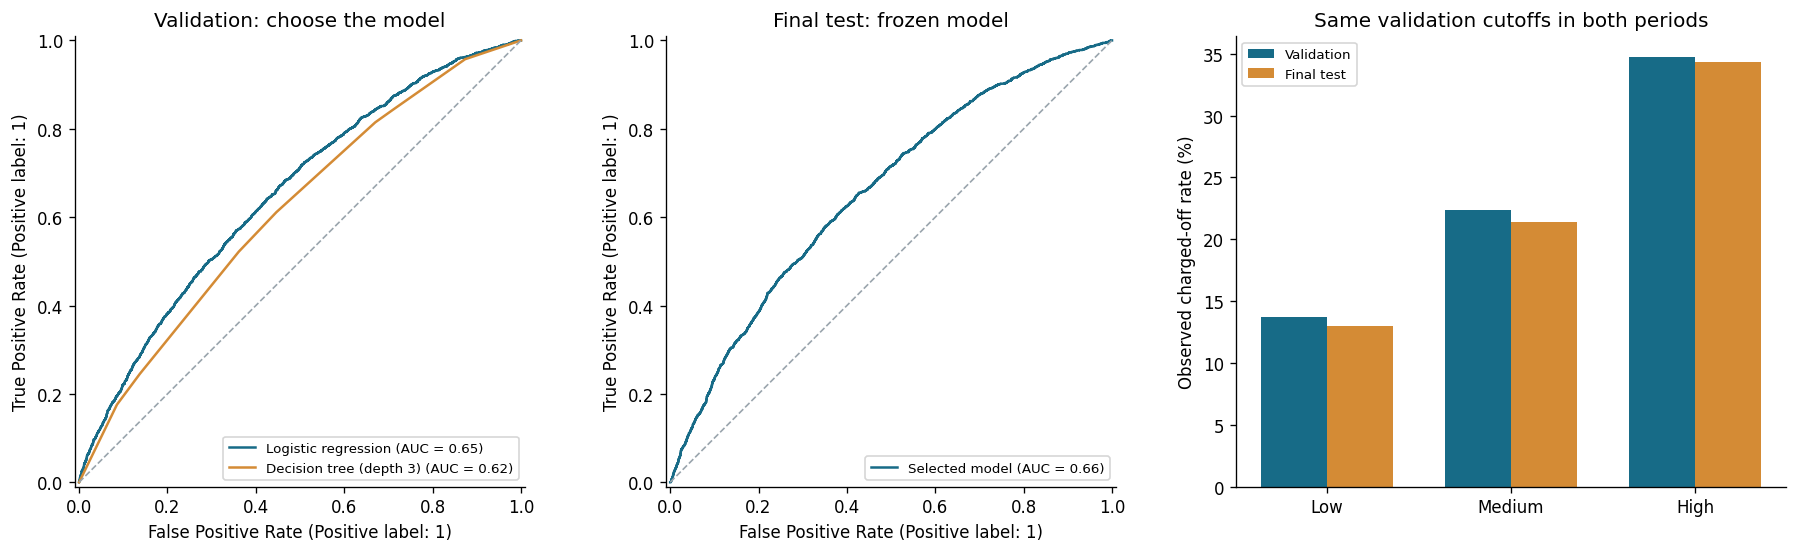

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), layout='constrained')
colors = ['#176B87', '#D48B35']
for (name, scores), color in zip(validation_scores.items(), colors):
    RocCurveDisplay.from_predictions(y_validation, scores, name=name, ax=axes[0], color=color)
RocCurveDisplay.from_predictions(test.charged_off, test_scores, name='Selected model',
                                 ax=axes[1], color=colors[0])
for ax, title in zip(axes[:2], ['Validation: choose the model', 'Final test: frozen model']):
    ax.plot([0, 1], [0, 1], '--', color='#9AA5AD', linewidth=1)
    ax.set_title(title)
    ax.legend(fontsize=8, loc='lower right')
x = np.arange(3)
axes[2].bar(x - .18, validation_bands.observed_rate * 100, .36, label='Validation', color=colors[0])
axes[2].bar(x + .18, test_bands.observed_rate * 100, .36, label='Final test', color=colors[1])
axes[2].set_xticks(x, ['Low', 'Medium', 'High'])
axes[2].set_ylabel('Observed charged-off rate (%)')
axes[2].set_title('Same validation cutoffs in both periods')
axes[2].legend(fontsize=8)
plt.show()

## 8. Explain the models without overstating them

The logistic table below shows the numeric coefficients: positive weights raise the
score, conditional on the other included inputs. Each weight is per one training
standard deviation of the transformed input. Associations are not causal effects.
The tree text exposes every rule; its numeric split thresholds use the standardized
pipeline scale. Both are deliberately small enough to inspect.

In [11]:
logistic = models['Logistic regression']
names = logistic.named_steps['prepare'].get_feature_names_out()
coefficients = pd.DataFrame({'feature': names, 'log_odds_coefficient':
                             logistic.named_steps['model'].coef_[0]})
display(coefficients[~coefficients.feature.str.startswith('category__')].reset_index(drop=True))
tree = models['Decision tree (depth 3)']
print(export_text(tree.named_steps['model'],
                  feature_names=list(tree.named_steps['prepare'].get_feature_names_out()), decimals=2))
print('Tree depth:', tree.named_steps['model'].get_depth(),
      '| leaves:', tree.named_steps['model'].get_n_leaves())

,feature,log_odds_coefficient
0,money__revenue,-0.2944
1,money__loan_amnt,0.3971
2,numeric__dti_n,0.1950
3,numeric__fico_n,-0.3891


|--- numeric__fico_n <= 0.08
|   |--- money__loan_amnt <= -0.25
|   |   |--- numeric__dti_n <= 1.02
|   |   |   |--- class: 0
|   |   |--- numeric__dti_n >  1.02
|   |   |   |--- class: 0
|   |--- money__loan_amnt >  -0.25
|   |   |--- numeric__dti_n <= 0.69
|   |   |   |--- class: 0
|   |   |--- numeric__dti_n >  0.69
|   |   |   |--- class: 0
|--- numeric__fico_n >  0.08
|   |--- numeric__dti_n <= 0.46
|   |   |--- numeric__fico_n <= 1.06
|   |   |   |--- class: 0
|   |   |--- numeric__fico_n >  1.06
|   |   |   |--- class: 0
|   |--- numeric__dti_n >  0.46
|   |   |--- numeric__fico_n <= 1.06
|   |   |   |--- class: 0
|   |   |--- numeric__fico_n >  1.06
|   |   |   |--- class: 0

Tree depth: 3 | leaves: 8


## 9. Boundary and missing-input checks

Use the adjacent representable floating-point numbers, not arbitrary rounded epsilons,
to check the exact cutoff behavior. Also test a missing essential input through the
complete application wrapper, plus optional missing and unseen categories.

In [12]:
cases = [
    ('zero', 0.0, 'approve'),
    ('just below lower', np.nextafter(low_cutoff, -np.inf), 'approve'),
    ('exact lower', low_cutoff, 'review'),
    ('just above lower', np.nextafter(low_cutoff, np.inf), 'review'),
    ('just below upper', np.nextafter(high_cutoff, -np.inf), 'review'),
    ('exact upper', high_cutoff, 'decline'),
    ('just above upper', np.nextafter(high_cutoff, np.inf), 'decline'),
    ('one', 1.0, 'decline'),
    ('missing score', None, 'review'),
    ('NaN score', np.nan, 'review'),
    ('infinite score', np.inf, 'review'),
    ('negative score', -0.1, 'review'),
    ('above one', 1.1, 'review'),
    ('text score', '0.1', 'review'),
    ('boolean score', True, 'review'),
]
checks = pd.DataFrame([{'case': label, 'score': score, 'expected': expected,
                        'actual': route_score(score)} for label, score, expected in cases])
checks['passed'] = checks.expected.eq(checks.actual)
assert checks.passed.all()
display(checks.assign(score=checks.score.map(
    lambda value: format(value, '.17g') if isinstance(value, Real) else str(value))))

example = {'revenue': 65_000., 'dti_n': 18., 'loan_amnt': 12_000.,
           'fico_n': 702., 'emp_length': '3 years', 'purpose': 'debt_consolidation'}
application_checks = []
for field in NUMERIC:
    incomplete = dict(example)
    incomplete.pop(field)
    result = route_application(incomplete)
    assert result['decision'] == 'review' and result['score'] is None
    application_checks.append({'case': f'Missing {field}', **result})
for label, change in [('Invalid FICO', {'fico_n': 900.}),
                       ('Negative DTI', {'dti_n': -1.}),
                       ('Zero income', {'revenue': 0.}),
                       ('Infinite amount', {'loan_amnt': np.inf})]:
    result = route_application({**example, **change})
    assert result['decision'] == 'review' and result['score'] is None
    application_checks.append({'case': label, **result})
for label, change in [('Complete example', {}), ('Missing employment', {'emp_length': None}),
                       ('Unseen purpose', {'purpose': 'new_category_for_test'})]:
    result = route_application({**example, **change})
    assert 0 <= result['score'] <= 1
    assert result['decision'] == route_score(result['score'])
    application_checks.append({'case': label, **result})
display(pd.DataFrame(application_checks))
assert frozen_cutoffs == (low_cutoff, high_cutoff)
assert sum(test_routing.loans) == len(test)
check_count = len(checks) + len(application_checks)
print(f'All {check_count} routing checks passed. Split and SQL reconciliation assertions also passed.')

,case,score,expected,actual,passed
0,zero,0,approve,approve,True
1,just below lower,0.13704533013883916,approve,approve,True
2,exact lower,0.13704533013883918,review,review,True
3,just above lower,0.13704533013883921,review,review,True
4,just below upper,0.212671503643205,review,review,True
5,exact upper,0.21267150364320503,decline,decline,True
6,just above upper,0.21267150364320506,decline,decline,True
7,one,1,decline,decline,True
8,missing score,None,review,review,True
9,NaN score,nan,review,review,True


,case,decision,score,reason
0,Missing revenue,review,NaN,Missing/invalid revenue
1,Missing dti_n,review,NaN,Missing/invalid dti_n
2,Missing loan_amnt,review,NaN,Missing/invalid loan_amnt
3,Missing fico_n,review,NaN,Missing/invalid fico_n
4,Invalid FICO,review,NaN,Out-of-range fico_n
5,Negative DTI,review,NaN,Out-of-range dti_n
6,Zero income,review,NaN,Out-of-range revenue
7,Infinite amount,review,NaN,Missing/invalid loan_amnt
8,Complete example,review,0.1502,Illustrative score rule
9,Missing employment,review,0.1925,Illustrative score rule


All 26 routing checks passed. Split and SQL reconciliation assertions also passed.


## 10. What the evidence supports

- **Funded-loan selection:** rejected applications are absent. Routing sorts historical
  funded loans; it cannot estimate rejected applicants' outcomes or policy impact.
- **Resolved-loan selection:** unresolved loans are excluded. Recent cohorts have less
  opportunity to mature; cohort outcome-rate changes can reflect this selection.
- **No as-of-label backtest:** resolution timestamps are unavailable, so early-cohort
  outcomes may not yet have been known at the next origination cutoff.
- **No fixed horizon:** the binary target describes eventual observed resolution, not
  one-year PD. Different loan durations and follow-up lengths are not modelled.
- **Modest scope:** one 50,000-row sample, two fixed models, no uncertainty intervals,
  economic loss model, fairness assessment or calibration study. AUC differences are
  descriptive, not evidence of statistical significance. Numeric imputation is available
  but not empirically stressed if this sample has no numeric missingness.
- **Transferability:** historical US marketplace lending is not an Austrian bank portfolio.
  The useful demonstration is audit discipline, SQL reconciliation, time-based validation
  and explicit decision boundaries.

**Interview explanation:** “I audited curated public records, used SQL to reconcile cohort
and purpose totals, fitted preprocessing only on earlier loans, chose between two simple
models using 2016 loans, and tested the unchanged selection on 2017–2018 originations.
The rule illustrates score routing; it does not claim to approve real applicants.”

In [13]:
display(Markdown(
    f"50,000 loans analysed. {selected_name} was selected on validation "
    f"(ROC-AUC {validation_auc[selected_name]:.4f}) and scored "
    f"{test_auc:.4f} on the later test. All {check_count} routing checks passed."
))

50,000 loans analysed. Logistic regression was selected on validation (ROC-AUC 0.6512) and scored 0.6568 on the later test. All 26 routing checks passed.